# 05 — Combinação Linear
**Referência:** Boldrini et al., Seção 4.4, p. 112–114

---

## 5.1 Definição (Boldrini, p. 112)

Um vetor $v \in V$ é uma **combinação linear** de $v_1, v_2, \ldots, v_n \in V$ se existem escalares $\alpha_1, \ldots, \alpha_n \in \mathbb{R}$ tais que:

$$v = \alpha_1 v_1 + \alpha_2 v_2 + \cdots + \alpha_n v_n$$

Os $\alpha_i$ são chamados de **coeficientes** da combinação linear.

---

## 5.2 Como Verificar

Verificar se $v$ é combinação linear de $v_1, \ldots, v_n$ equivale a **resolver um sistema linear** nos $\alpha_i$:

$$[v_1 \mid v_2 \mid \cdots \mid v_n] \cdot \begin{pmatrix}\alpha_1 \\ \vdots \\ \alpha_n\end{pmatrix} = v$$

- Se o sistema **tem solução** → $v$ é CL ✓
- Se o sistema **não tem solução** → $v$ não é CL ✗


In [1]:
from sympy import Matrix, symbols, linsolve, pprint
from sympy import init_printing
init_printing(use_unicode=True)

# ── Exemplo 1: v É combinação linear ─────────────────
print("Exemplo: v1=(1,0,1), v2=(0,1,1), v=(2,3,5)")
print("Verificar se v = α·v1 + β·v2")
print()

v1 = Matrix([1, 0, 1])
v2 = Matrix([0, 1, 1])
v  = Matrix([2, 3, 5])

# Montar matriz com v1 e v2 como COLUNAS
M = v1.row_join(v2)
print("Matriz [v1|v2]:"); pprint(M)
print("\nvetor b = v:"); pprint(v)

alpha, beta = symbols('alpha beta')
sol = linsolve((M, v), alpha, beta)
print(f"\nSolução: (α, β) = {sol}")


Exemplo: v1=(1,0,1), v2=(0,1,1), v=(2,3,5)
Verificar se v = α·v1 + β·v2

Matriz [v1|v2]:
⎡1  0⎤
⎢    ⎥
⎢0  1⎥
⎢    ⎥
⎣1  1⎦

vetor b = v:
⎡2⎤
⎢ ⎥
⎢3⎥
⎢ ⎥
⎣5⎦

Solução: (α, β) = {(2, 3)}


In [2]:
# Verificação visual
sol_vals = list(sol)[0]
a_val, b_val = sol_vals
resultado = a_val * v1 + b_val * v2
print(f"Verificação: {a_val}·v1 + {b_val}·v2 = {resultado.T}")
print(f"v = {v.T}")
print(f"Iguais? {resultado == v}  ✓")


Verificação: 2·v1 + 3·v2 = Matrix([[2, 3, 5]])
v = Matrix([[2, 3, 5]])
Iguais? True  ✓


In [3]:
# ── Exemplo 2: v NÃO é combinação linear ─────────────
print("Exemplo: v1=(1,0,0), v2=(0,1,0), v=(0,0,1)")
print("Verificar se v = α·v1 + β·v2")
print()

v1b = Matrix([1, 0, 0])
v2b = Matrix([0, 1, 0])
vb  = Matrix([0, 0, 1])

Mb = v1b.row_join(v2b)
amp = Mb.row_join(vb)
rref, _ = amp.rref()
print("Forma escalonada [v1|v2|v]:"); pprint(rref)
print()
print(f"Posto [v1|v2] = {Mb.rank()}")
print(f"Posto [v1|v2|v] = {amp.rank()}")
print()
if Mb.rank() != amp.rank():
    print("Postos diferentes → sistema impossível → v NÃO é CL de v1, v2  ✗")


Exemplo: v1=(1,0,0), v2=(0,1,0), v=(0,0,1)
Verificar se v = α·v1 + β·v2

Forma escalonada [v1|v2|v]:
⎡1  0  0⎤
⎢       ⎥
⎢0  1  0⎥
⎢       ⎥
⎣0  0  1⎦

Posto [v1|v2] = 2
Posto [v1|v2|v] = 3

Postos diferentes → sistema impossível → v NÃO é CL de v1, v2  ✗


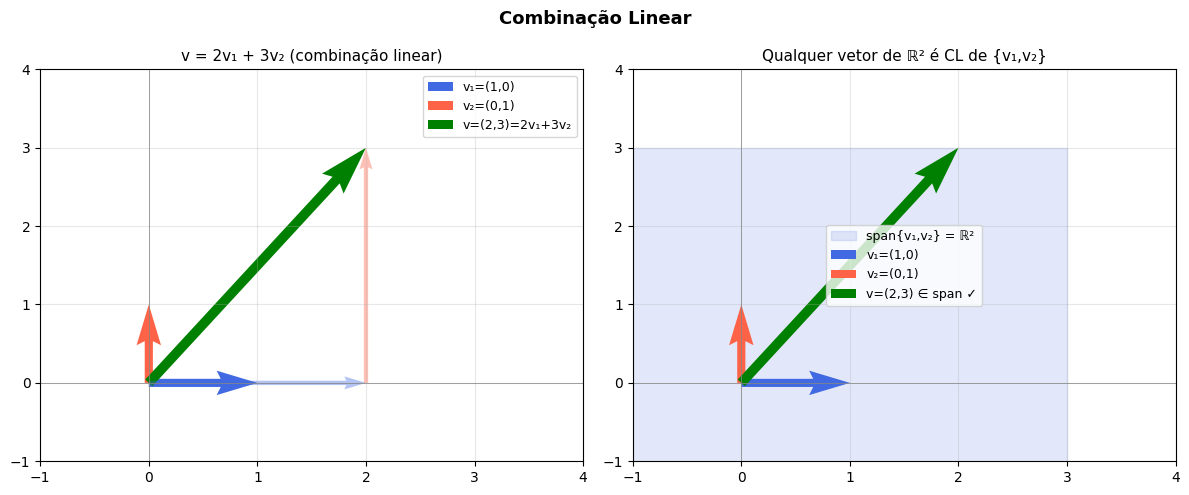

In [4]:
# ── Visualização: CL no plano ─────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

v1_np = np.array([1, 0])
v2_np = np.array([0, 1])
v_np  = np.array([2, 3])
origin = np.array([0, 0])

# Gráfico 1: decomposição em CL
ax = axes[0]
ax.quiver(*origin, *v1_np, color='royalblue', angles='xy', scale_units='xy', scale=1, width=0.015, label='v₁=(1,0)')
ax.quiver(*origin, *v2_np, color='tomato', angles='xy', scale_units='xy', scale=1, width=0.015, label='v₂=(0,1)')
ax.quiver(*origin, *v_np,  color='green',  angles='xy', scale_units='xy', scale=1, width=0.018, label='v=(2,3)=2v₁+3v₂')
ax.quiver(*origin, *2*v1_np, color='royalblue', angles='xy', scale_units='xy', scale=1, width=0.008, alpha=0.4)
ax.quiver(*2*v1_np, *3*v2_np, color='tomato', angles='xy', scale_units='xy', scale=1, width=0.008, alpha=0.4)
ax.set_xlim(-1, 4); ax.set_ylim(-1, 4)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
ax.set_title('v = 2v₁ + 3v₂ (combinação linear)', fontsize=11)

# Gráfico 2: espaço gerado vs vetor de fora
ax = axes[1]
t = np.linspace(-3, 3, 100)
ax.fill_between([-3, 3], [-3, -3], [3, 3], alpha=0.15, color='royalblue', label='span{v₁,v₂} = ℝ²')
ax.quiver(*origin, 1, 0, color='royalblue', angles='xy', scale_units='xy', scale=1, width=0.015, label='v₁=(1,0)')
ax.quiver(*origin, 0, 1, color='tomato', angles='xy', scale_units='xy', scale=1, width=0.015, label='v₂=(0,1)')
ax.quiver(*origin, 2, 3, color='green', angles='xy', scale_units='xy', scale=1, width=0.018, label='v=(2,3) ∈ span ✓')
ax.set_xlim(-1, 4); ax.set_ylim(-1, 4)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
ax.set_title('Qualquer vetor de ℝ² é CL de {v₁,v₂}', fontsize=11)

plt.suptitle('Combinação Linear', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 📝 Exercícios

1. Verifique se $v=(3,1)$ é CL de $v_1=(1,0)$ e $v_2=(1,1)$.
2. Verifique se $v=(1,1,2)$ é CL de $v_1=(1,0,1)$ e $v_2=(0,1,1)$.
3. Expresse o polinômio $p(x)=3+x$ como CL de $p_1=1$ e $p_2=x$.


In [5]:
from sympy import Matrix, symbols, linsolve
a, b = symbols('alpha beta')

# Ex. 1
v1, v2, v = Matrix([1,0]), Matrix([1,1]), Matrix([3,1])
M = v1.row_join(v2)
print("Ex.1:", linsolve((M, v), a, b))

# Ex. 2
v1b, v2b, vb = Matrix([1,0,1]), Matrix([0,1,1]), Matrix([1,1,2])
Mb = v1b.row_join(v2b)
print("Ex.2:", linsolve((Mb, vb), a, b))

# Ex. 3
print("Ex.3: 3+x = 3·(1) + 1·(x)  → α=3, β=1")


Ex.1: {(2, 1)}
Ex.2: {(1, 1)}
Ex.3: 3+x = 3·(1) + 1·(x)  → α=3, β=1
